## **Facebook Metrics Exploratory Data Anaylsis**

Commencing the initial clean-up on the data and explore what can be done with the data.

Start by looking for any numerical outliers as well as plotting out some basic information from the data. Based on these plots and the domain knowledge I have, I'll begin making a plan as to how I wish to further analyze the data. 

The goal of this EDA is to understand how different features relate to each other and begin to consider which key features I'd like to pursue first in my analysis of the data. At the end of this report, there should be a good understanding of how the Facebook metrics data is distributed.

Data retrieved from [UC Irvine Machine Learning Repository](https://archive.ics.uci.edu/dataset/368/facebook+metrics). Facebook performance metrics of a renowned cosmetic's brand Facebook page. The data is related to posts' published during 2014. Metrics donated 08/04/2016. This dataset is licensed under a [Creative Commons Attribution 4.0 International](https://creativecommons.org/licenses/by/4.0/legalcode), (CC BY 4.0) license which allows for the sharing and adaptation of the datasets for any purpose, provided that the appropriate credit is given.

Additional Variable Information: it includes seven (7) features known prior to post publication and twelve (12) features for evaluating post impact.

**Citation:** (Moro et al., 2016) S. Moro, P. Rita and B. Vala. Predicting social media performance metrics and evaluation of the impact on brand building: A data mining approach. Journal of Business Research, Elsevier, In press.
 
Available at: https://dx.doi.org/10.1016/j.jbusres.2016.02.010

In [1]:
# As always, let's begin with imports.
# Importing pandas and numpy for our numerical analysis
# Importing pyplot and seaborn in order to visualize the data

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import ticker
import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore')

## **Data Loading & Preliminary Exploration**

In [2]:
# Loading the data
# Used sep= to correct error read_csv as 1 column
df = pd.read_csv('C:/Users/winni/Fb-Metrics-Modeling/D@ta/dataset_Facebook.csv', sep=';')

In [3]:
# Using shape function to return tuple of number of rows and columns in the DataFrame.
print("Shape:", df.shape)

Shape: (500, 19)


In [4]:
# Using head() function to view first few rows of data and get a better sense of what we're working with.
df.head()

,Page total likes,Type,Category,Post Month,Post Weekday,Post Hour,Paid,Lifetime Post Total Reach,Lifetime Post Total Impressions,Lifetime Engaged Users,Lifetime Post Consumers,Lifetime Post Consumptions,Lifetime Post Impressions by people who have liked your Page,Lifetime Post reach by people who like your Page,Lifetime People who have liked your Page and engaged with your post,comment,like,share,Total Interactions
0,139441,Photo,2,12,4,3,0.0,2752,5091,178,109,159,3078,1640,119,4,79.0,17.0,100
1,139441,Status,2,12,3,10,0.0,10460,19057,1457,1361,1674,11710,6112,1108,5,130.0,29.0,164
2,139441,Photo,3,12,3,3,0.0,2413,4373,177,113,154,2812,1503,132,0,66.0,14.0,80
3,139441,Photo,2,12,2,10,1.0,50128,87991,2211,790,1119,61027,32048,1386,58,1572.0,147.0,1777
4,139441,Photo,2,12,2,3,0.0,7244,13594,671,410,580,6228,3200,396,19,325.0,49.0,393


In [5]:
# Begin exploring the data by using info() function to get reminder of what data is present, number of rows/columns, data types, etc.
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 19 columns):
 #   Column                                                               Non-Null Count  Dtype  
---  ------                                                               --------------  -----  
 0   Page total likes                                                     500 non-null    int64  
 1   Type                                                                 500 non-null    object 
 2   Category                                                             500 non-null    int64  
 3   Post Month                                                           500 non-null    int64  
 4   Post Weekday                                                         500 non-null    int64  
 5   Post Hour                                                            500 non-null    int64  
 6   Paid                                                                 499 non-null    float64
 7   Lifetime

#### *<p style="text-align:center;"><b>Exploring & Altering columns</b>*

In [6]:
# Replacing the space in column names with underscores
df.columns = df.columns.str.replace(' ', '_')
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 19 columns):
 #   Column                                                               Non-Null Count  Dtype  
---  ------                                                               --------------  -----  
 0   Page_total_likes                                                     500 non-null    int64  
 1   Type                                                                 500 non-null    object 
 2   Category                                                             500 non-null    int64  
 3   Post_Month                                                           500 non-null    int64  
 4   Post_Weekday                                                         500 non-null    int64  
 5   Post_Hour                                                            500 non-null    int64  
 6   Paid                                                                 499 non-null    float64
 7   Lifetime

In [7]:
# Shortening some column names to make it easier to use in subsequent queries
# Verify if renaming worked with print() function
df = df.rename(columns={'Lifetime_Post_Total_Reach': 'Lt_Post_Total_Rch', 'Lifetime_Post_Total_Impressions': 'Lt_Post_Total_Impsn', 'Lifetime_Engaged_Users': 'Lt_Eng_Users', 'Lifetime_Post_Consumers': 'Lt_Post_Cnsmrs', 'Lifetime_Post_Consumptions': 'Lt_Post_Cnsmp', 'Lifetime_Post_Impressions_by_people_who_have_liked_your_Page': 'Lt_Post_Imp_Ppl_Lk_Pg', 'Lifetime_Post_reach_by_people_who_like_your_Page': 'Lt_Post_Rch_Ppl_Lk_Pg', 'Lifetime_People_who_have_liked_your_Page_and_engaged_with_your_post': 'Lt_Ppl_Lk_Pg_Eng_Post'})
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 19 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Page_total_likes       500 non-null    int64  
 1   Type                   500 non-null    object 
 2   Category               500 non-null    int64  
 3   Post_Month             500 non-null    int64  
 4   Post_Weekday           500 non-null    int64  
 5   Post_Hour              500 non-null    int64  
 6   Paid                   499 non-null    float64
 7   Lt_Post_Total_Rch      500 non-null    int64  
 8   Lt_Post_Total_Impsn    500 non-null    int64  
 9   Lt_Eng_Users           500 non-null    int64  
 10  Lt_Post_Cnsmrs         500 non-null    int64  
 11  Lt_Post_Cnsmp          500 non-null    int64  
 12  Lt_Post_Imp_Ppl_Lk_Pg  500 non-null    int64  
 13  Lt_Post_Rch_Ppl_Lk_Pg  500 non-null    int64  
 14  Lt_Ppl_Lk_Pg_Eng_Post  500 non-null    int64  
 15  commen

##### *Per the source paper, the top feature column **Category** is a manual content chaacterization:*
+ *<u>*action*</u> (special offers & contests),* 
+ *<u>*product</u>* (direct advertisement, explicit brand content),* 
+ *<u>*inspiration*</u> (non-explicit brand related content)*

In [8]:
# Using value_counts() function to gain more insights into this vaguely worded column "Category"
df["Category"].value_counts()

Category
1    215
3    155
2    130
Name: count, dtype: int64

<Axes: ylabel='Category'>

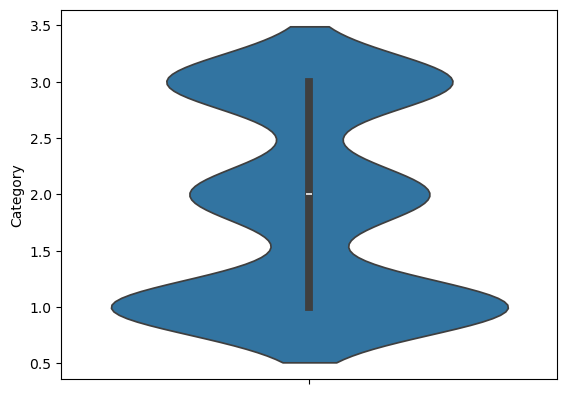

In [9]:
# Seaborn violinplot of the Category' column
sns.violinplot(df['Category'])

#### *<p style="text-align:center;">Additional <b>feature columns</b> used in their model*
<br>
![Fb_metrics feat dscrptn.png](<attachment:Fb_metrics feat dscrptn.png>)
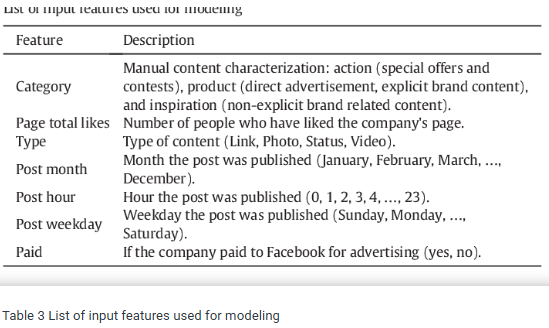

In [10]:
# Find the number of each object in the 'Type' column
df['Type'].value_counts()

Type
Photo     426
Status     45
Link       22
Video       7
Name: count, dtype: int64

<Axes: xlabel='count', ylabel='Type'>

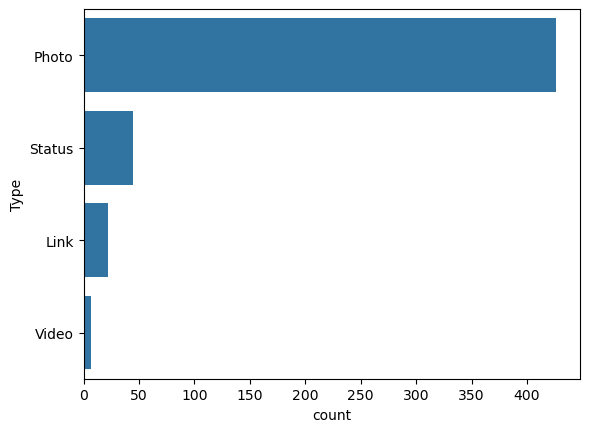

In [11]:
# Seaborn countplot of the categories in the 'Type' column
sns.countplot(df['Type'])

#### *<p style="text-align:center;"><b>Missing Values</b>*

In [12]:
# Finding missing values and if relevant, consider altering or dropping
missing = df.isna().sum()
missing_pct = (missing / len(df) * 100).round(2)

pd.DataFrame({'count': missing, 'percent': missing_pct})

,count,percent
Page_total_likes,0,0.0
Type,0,0.0
Category,0,0.0
Post_Month,0,0.0
Post_Weekday,0,0.0
Post_Hour,0,0.0
Paid,1,0.2
Lt_Post_Total_Rch,0,0.0
Lt_Post_Total_Impsn,0,0.0
Lt_Eng_Users,0,0.0


In [13]:
# trying something else
df_pd = df[df.Paid.isna()]

df_lk = df[df.like.isna()]

df_sh = df[df.share.isna()]

In [14]:
# Missing rows in 'Paid' column
df_pd.head()

,Page_total_likes,Type,Category,Post_Month,Post_Weekday,Post_Hour,Paid,Lt_Post_Total_Rch,Lt_Post_Total_Impsn,Lt_Eng_Users,Lt_Post_Cnsmrs,Lt_Post_Cnsmp,Lt_Post_Imp_Ppl_Lk_Pg,Lt_Post_Rch_Ppl_Lk_Pg,Lt_Ppl_Lk_Pg_Eng_Post,comment,like,share,Total_Interactions
499,81370,Photo,2,1,4,4,NaN,4188,7292,564,524,743,3861,2200,316,0,91.0,28.0,119


In [15]:
# Missing rows in 'like' column
df_lk.head()

,Page_total_likes,Type,Category,Post_Month,Post_Weekday,Post_Hour,Paid,Lt_Post_Total_Rch,Lt_Post_Total_Impsn,Lt_Eng_Users,Lt_Post_Cnsmrs,Lt_Post_Cnsmp,Lt_Post_Imp_Ppl_Lk_Pg,Lt_Post_Rch_Ppl_Lk_Pg,Lt_Ppl_Lk_Pg_Eng_Post,comment,like,share,Total_Interactions
111,136736,Photo,1,10,6,8,0.0,1261,2158,37,37,49,1911,1077,33,0,NaN,NaN,0


In [16]:
# Missing rows in 'share' column
df_sh.head()

,Page_total_likes,Type,Category,Post_Month,Post_Weekday,Post_Hour,Paid,Lt_Post_Total_Rch,Lt_Post_Total_Impsn,Lt_Eng_Users,Lt_Post_Cnsmrs,Lt_Post_Cnsmp,Lt_Post_Imp_Ppl_Lk_Pg,Lt_Post_Rch_Ppl_Lk_Pg,Lt_Ppl_Lk_Pg_Eng_Post,comment,like,share,Total_Interactions
111,136736,Photo,1,10,6,8,0.0,1261,2158,37,37,49,1911,1077,33,0,NaN,NaN,0
120,136393,Photo,1,10,7,9,0.0,584,1029,273,271,308,943,511,232,0,2.0,NaN,2
124,136393,Photo,1,10,7,6,0.0,677,1285,251,246,297,1210,615,211,0,7.0,NaN,7
164,135428,Photo,1,9,5,10,0.0,1060,2004,266,251,337,1705,870,204,0,18.0,NaN,18


#### *<p style="text-align:center;"><b>Summary Statistics</b>*

In [17]:
# Using describe() function and rounding output as two (2) decimal points. 
# Output is basic descriptive and statistics for each columns.
df.describe().round(2)

,Page_total_likes,Category,Post_Month,Post_Weekday,Post_Hour,Paid,Lt_Post_Total_Rch,Lt_Post_Total_Impsn,Lt_Eng_Users,Lt_Post_Cnsmrs,Lt_Post_Cnsmp,Lt_Post_Imp_Ppl_Lk_Pg,Lt_Post_Rch_Ppl_Lk_Pg,Lt_Ppl_Lk_Pg_Eng_Post,comment,like,share,Total_Interactions
count,500.00,500.00,500.00,500.00,500.00,499.00,500.00,500.00,500.00,500.00,500.00,500.00,500.00,500.00,500.00,499.00,496.00,500.00
mean,123194.18,1.88,7.04,4.15,7.84,0.28,13903.36,29585.95,920.34,798.77,1415.13,16766.38,6585.49,609.99,7.48,177.95,27.27,212.12
std,16272.81,0.85,3.31,2.03,4.37,0.45,22740.79,76803.25,985.02,882.51,2000.59,59791.02,7682.01,612.73,21.18,323.40,42.61,380.23
min,81370.00,1.00,1.00,1.00,1.00,0.00,238.00,570.00,9.00,9.00,9.00,567.00,236.00,9.00,0.00,0.00,0.00,0.00
25%,112676.00,1.00,4.00,2.00,3.00,0.00,3315.00,5694.75,393.75,332.50,509.25,3969.75,2181.50,291.00,1.00,56.50,10.00,71.00
50%,129600.00,2.00,7.00,4.00,9.00,0.00,5281.00,9051.00,625.50,551.50,851.00,6255.50,3417.00,412.00,3.00,101.00,19.00,123.50
75%,136393.00,3.00,10.00,6.00,11.00,1.00,13168.00,22085.50,1062.00,955.50,1463.00,14860.50,7989.00,656.25,7.00,187.50,32.25,228.50
max,139441.00,3.00,12.00,7.00,23.00,1.00,180480.00,1110282.00,11452.00,11328.00,19779.00,1107833.00,51456.00,4376.00,372.00,5172.00,790.00,6334.00


---------------

### **<p style="text-align:center;">Target = Total Interactions (int64)**

---------------

## **Distribution Observations Visualization Exploration**

#### *<p style="text-align:center;"><b>Feature Distributions</b>*

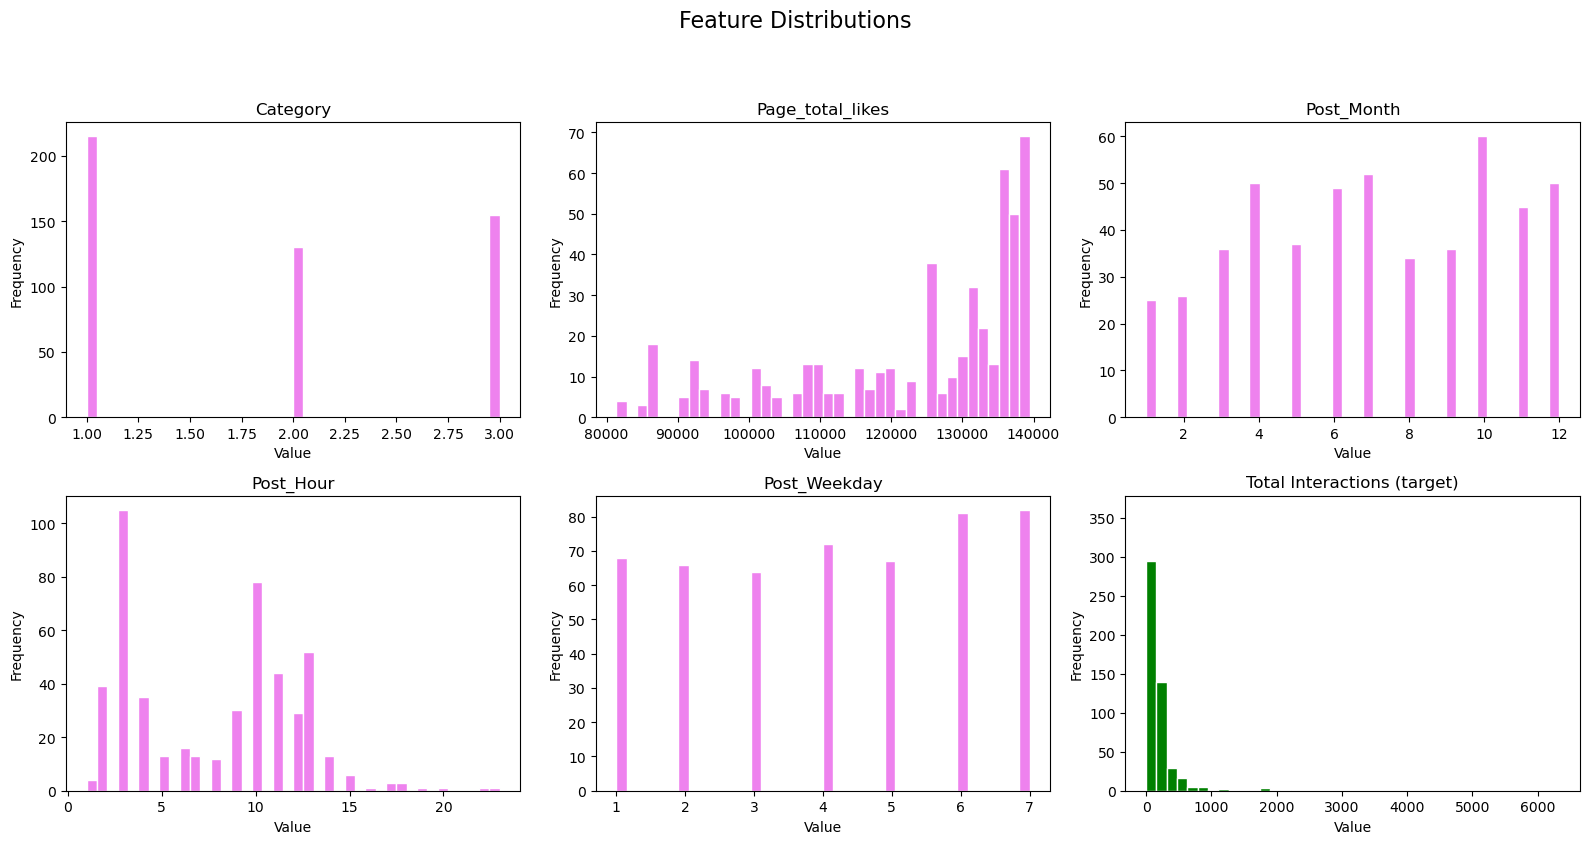

In [18]:
# Feature distributions without 'Type' column, which will get-dummied in the transform stage.
features = ['Category', 'Page_total_likes', 'Post_Month', 'Post_Hour', 'Post_Weekday', 'Paid']

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()

for i, col in enumerate(features):
    axes[i].hist(df[col].dropna(), bins=40, color='violet', edgecolor='white')
    axes[i].set_title(col)
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Frequency')

axes[-1].hist(df['Total_Interactions'], bins=40, color='green', edgecolor='white')
axes[-1].set_title('Total Interactions (target)')
axes[-1].set_xlabel('Value')

plt.suptitle('Feature Distributions', fontsize=16, y=1.05)
plt.tight_layout()
plt.show()

Observations about feat dist
<br>
1. point 1
    + subpoint 1a
2. point 2
    + subpoint 2a
3. point 3
    + subpoint 3a

#### *<p style="text-align:center;"><b>Outlier Detection Boxplots (ODB)</b>*

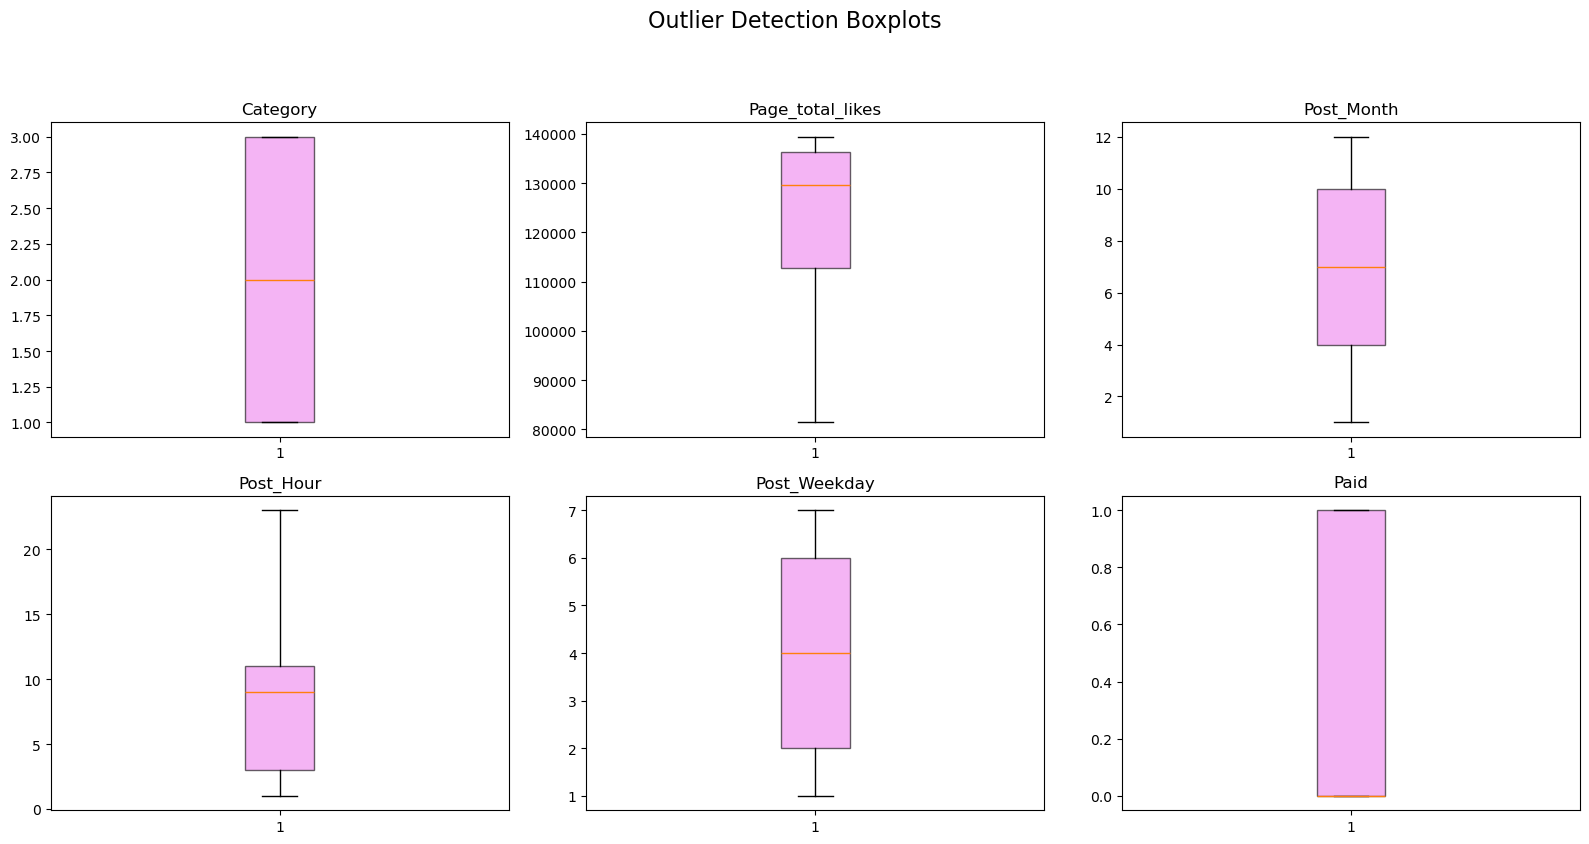

In [19]:
# Outlier detection without 'Type' column, which will be handled in the transform stage.
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()

all_cols = ['Category', 'Page_total_likes', 'Post_Month',
            'Post_Hour', 'Post_Weekday', 'Paid']

for i, col in enumerate(all_cols):
    axes[i].boxplot(df[col].dropna(), vert=True, patch_artist=True,
                    boxprops=dict(facecolor='violet', alpha=0.6))
    axes[i].set_title(col)

plt.suptitle('Outlier Detection Boxplots', fontsize=16, y=1.05)
plt.tight_layout()
plt.show()

Observations about boxplot
<br>
1. point 1
    + subpoint 1a
2. point 2
    + subpoint 2a
3. point 3
    + subpoint 3a

In [20]:
# code to print certain outliers & what to do next


OOO: Other Outlier Observations
<br>
1. point 1
    + subpoint 1a
2. point 2
    + subpoint 2a

#### *<p style="text-align:center;"><b>Correlation Heatmaps</b>*

In [21]:
# Finding initial relationships between columns in the dataset.
corr = df.corr(numeric_only=True).round(3)
print(corr)

                       Page_total_likes  Category  Post_Month  Post_Weekday  \
Page_total_likes                  1.000    -0.091       0.941        -0.005   
Category                         -0.091     1.000      -0.128        -0.053   
Post_Month                        0.941    -0.128       1.000         0.017   
Post_Weekday                     -0.005    -0.053       0.017         1.000   
Post_Hour                        -0.144    -0.107      -0.176         0.046   
Paid                              0.005    -0.022      -0.019        -0.002   
Lt_Post_Total_Rch                -0.083    -0.142      -0.103        -0.050   
Lt_Post_Total_Impsn              -0.103    -0.094      -0.102        -0.034   
Lt_Eng_Users                     -0.112     0.003      -0.116        -0.048   
Lt_Post_Cnsmrs                   -0.149    -0.031      -0.147        -0.030   
Lt_Post_Cnsmp                    -0.128    -0.149      -0.143        -0.022   
Lt_Post_Imp_Ppl_Lk_Pg            -0.096    -0.048   

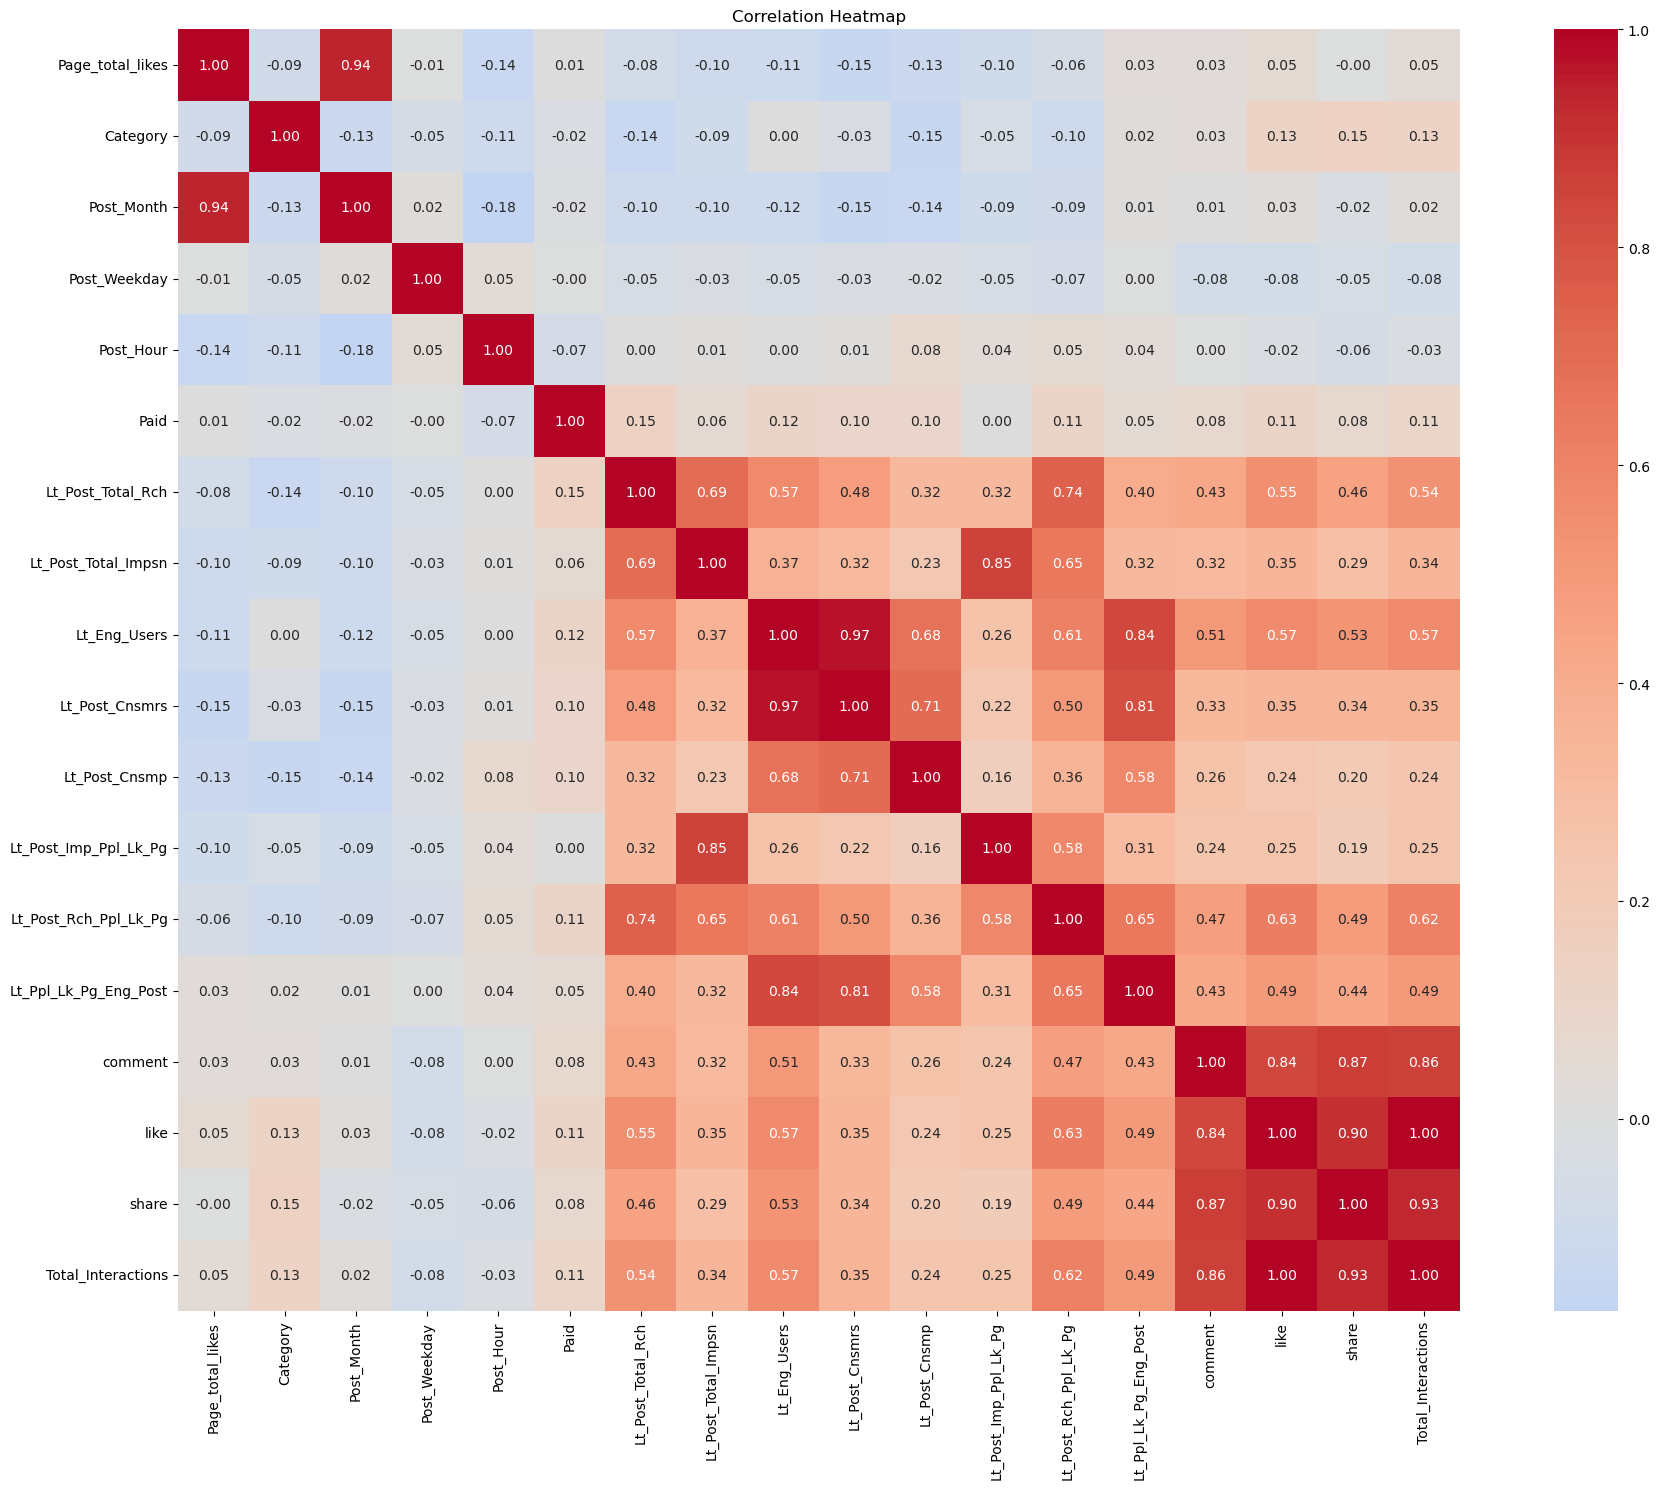

In [22]:
# Visualization of correlations using a heatmap 
#Adding plt.figure(figsize=(20,15)) to enhance size and readability --> figsize as a tuple

corr = df.corr(numeric_only=True)

plt.figure(figsize=(20,15))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, square=True)
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

In [23]:
# corr triangle sort - code courtesty of Cameron B > 0.5 or < -0.5

mask = np.triu(np.ones(corr.shape), k=1).astype(bool)
upper_triangle = corr.where(mask)
sorted_correlations = upper_triangle.stack().sort_values(ascending=False)
sorted_correlations

like              Total_Interactions    0.997705
Lt_Eng_Users      Lt_Post_Cnsmrs        0.968213
Page_total_likes  Post_Month            0.941192
share             Total_Interactions    0.928557
like              share                 0.904028
                                          ...   
Page_total_likes  Post_Hour            -0.143807
Post_Month        Lt_Post_Cnsmrs       -0.147083
Page_total_likes  Lt_Post_Cnsmrs       -0.149129
Category          Lt_Post_Cnsmp        -0.149443
Post_Month        Post_Hour            -0.176390
Length: 153, dtype: float64

Observations about heatmap
<br>
1. point 1
    + subpoint 1a
2. point 2
    + subpoint 2a
3. point 3
    + subpoint 3a

#### *<p style="text-align:center;"><b>Scatterplots & Pairplots</b>*

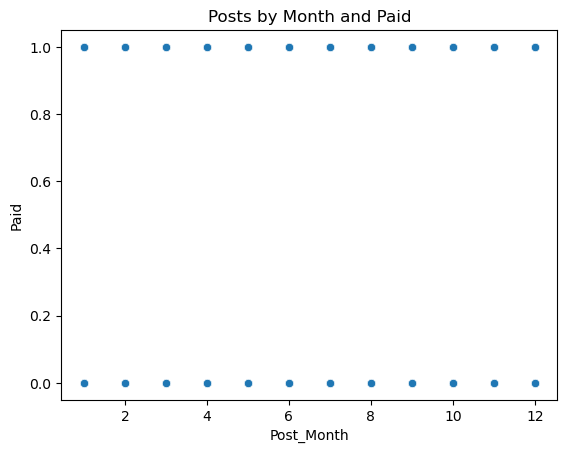

In [ ]:
# Scatterplot of month & paid
# NEED TO FIX VARIABLES

sns.scatterplot(
    x = 'Post_Month', y = 'Paid', 
    hue = None, style = None, size = None,
    data=df, legend='brief')
plt.title('Posts by Month and Paid')
plt.show()

In [37]:
# Scattetplot of Post Month

df.Post_Month

sns.scatterplot(data = df.Post_Month, x = 'Post_Month', y = None, center = 0, square = True, **kwargs: any)
plt.title('Post by Month')
plt.show()

SyntaxError: invalid syntax (3706175220.py, line 5)

In [ ]:
# Scattetplot of Post Day

day = df.Post_Weekday

sns.scatterplot(x='Day', y='Frequency', data=day, center=0, square=True)
plt.title('Post by Weekday')
plt.show()

In [ ]:
# Scattetplot of Post Hour

hour = df.Post_Hour

sns.scatterplot(x='Hour', y='Frequency', data=hour, center=0, square=True)
plt.title('Post by Hour')
plt.show()

In [38]:
# Pairplot
sns.pairplot(df, y_vars=['Total_Interactions'], 
    x_vars =[df.columns],
    plot_kws={'alpha': 0.4, 's': 15})

plt.suptitle('Pairplot', fontsize=14, y=1.05)
plt.tight_layout()
plt.show()

ValueError: The truth value of an array with more than one element is ambiguous. Use a.any() or a.all()

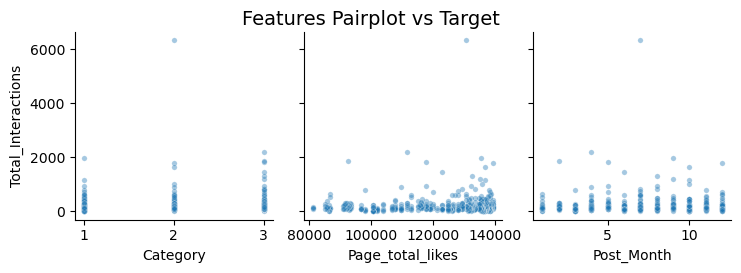

In [41]:
# Pairplot of features vs target part 1
sns.pairplot(df, y_vars=['Total_Interactions'], 
    x_vars =['Category', 'Page_total_likes', 'Post_Month'],
    plot_kws={'alpha': 0.4, 's': 15})

plt.suptitle('Features Pairplot vs Target', fontsize=14, y=1.05)
plt.show()

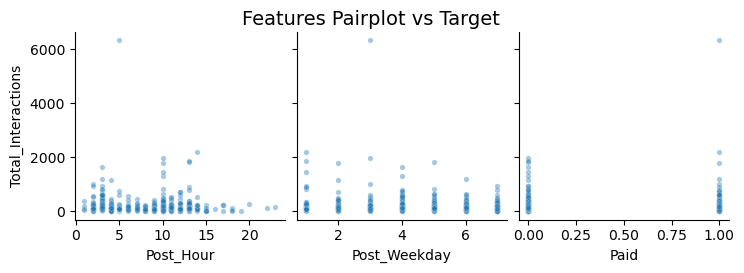

In [42]:
# Pairplot of features vs target part 2
sns.pairplot(df, y_vars=['Total_Interactions'], 
    x_vars =['Post_Hour', 'Post_Weekday', 'Paid'],
    plot_kws={'alpha': 0.4, 's': 15})

plt.suptitle('Features Pairplot vs Target', fontsize=14, y=1.05)
plt.show()

The Plot Thickens: Observations about the scatterplots & pairplots
<br>
1. point 1
    + subpoint 1a
2. point 2
    + subpoint 2a
3. point 3
    + subpoint 3a

---------------

## **Initial Thoughts**

The data 

Missing data points

Outliers

Range

Data Types ... how many of each... why want to look at them

Start getting counts of the data and look at the distribution of values. Then can assess how these features correlate/compare to `Total_Interactions`, our target variable. Next look for any initial insights that can be made from a simple 2-D analysis of the data.

First analysis will be with bar charts. `Total_Interactions` won't be included because it is the target. Adding it could skiws some of the initial analysis and it just doesn't make sense to include latest price in our bar charts.

A separate bar chart will be made for `Type` as it is the only object data type in the DataFrame. Based on that bar chart, would most likely convert the data type to string or integer. This should ensure the data works well in the model.

Also want to examine the columns that have Non-Null Counts less than 500. Might be able to drop some of those columns if irrelevant.

Another comparison would be between the columns that have similar names (i.e. 'Lifetime Post Total Reach' vs 'Lifetime Post Reach by people who like your page')

In [43]:
# Create a function that can count columns and their values.
# code currently doesn't work... need to redo or remove
def count_column(df,col_list):
    count = {}
    for elem in col_list:
        count(elem) == df[elem].value_counts()
    return count

#Dropping the target column 'Total Interactions
columns_to_count = df.columns
columns_to_count = columns_to_count.drop(['Total Interactions'])
fb_string_counts = count_column(df, columns_to_count)

KeyError: "['Total Interactions'] not found in axis"

In [ ]:
plt.figure(figsize = (15,40))


In [ ]:
# Expanding on the barchart we want to look at the breakdown

fig, ax = plt.subplots(figsize = (15,13))


In [ ]:
# Utilize heatmaps as another way of visualizing
plt.figure(figsize = (30,20))
sns.set(font_scale = 2)
sns.heatmap(df.corr(), annot=True);

In [ ]:
#Box plots for all of our features, analysis at the end
plt.subplots_adjust(hspace = 1.5)

---------------

## **Final Impressions**

The data 

Missing data points

Outliers

Range

Transform for what?!?